# Fig. 4a-g spatial, UMAP, and TLS panels

This notebook redraws the Fig. 4a-g spatial/UMAP panels from fixed h5ad outputs. It does not regenerate h5ad files.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

cwd = Path.cwd()
if (cwd / "figures_res" / "fig4").exists():
    REPO_ROOT = cwd
    FIG4_DIR = cwd / "figures_res" / "fig4"
elif cwd.name == "fig4" and (cwd / "output").exists():
    FIG4_DIR = cwd
    REPO_ROOT = cwd.parents[1]
else:
    raise FileNotFoundError("Run from repo root or figures_res/fig4.")

OUTPUT_DIR = FIG4_DIR / "output" / "a_g"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORIG_PATH = REPO_ROOT / "10x_tmp" / "WT.h5ad"
PARE_PATH = REPO_ROOT / "new_evaluations" / "spatial" / "downstream" / "reclustered_adata_test_woLasso_42_downstream.h5ad"
CELLENS_PATH = REPO_ROOT / "output" / "WT_celllens_full_res0.1"
SPAGCN_PATH = REPO_ROOT / "other_approaches" / "SpaGCN" / "do_spaGCN" / "sample_results" / "results_15clusters.h5ad"
GPCA_PATH = REPO_ROOT / "other_approaches" / "GraphPCA" / "do_gPCA" / "WT_gPCA.h5ad"

sns.set_theme(style="white", context="notebook")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

ORIGINAL_ANNOTATION = {
    "Cluster-1": "1-Plasma",
    "Cluster-2": "2-TLS",
    "Cluster-3": "3-Tumor_HER2",
    "Cluster-4": "4-TAMs",
    "Cluster-5": "5-Plasma",
    "Cluster-6": "6-Edge",
    "Cluster-7": "7-Endo",
    "Cluster-8": "8-Tumor_Epi",
    "Cluster-9": "9-Angio",
    "Cluster-10": "10-Tumor_Mito",
    "Cluster-11": "11-CAFs",
    "Cluster-12": "12-SMCs",
}
ORIGINAL_ORDER = list(ORIGINAL_ANNOTATION.values())

PARE_ANNOTATION = {
    "0": "0-TAMs",
    "1": "1-B_Cells",
    "2": "2-CAFs",
    "3": "3-Myeloid_Mixed",
    "4": "4-Plasma",
    "5": "5-Plasma",
    "6": "6-T_Cells",
    "7": "7-Endo",
    "8": "8-Tumor_Mito",
    "9": "9-T_Cells",
    "10": "10-Endo",
    "11": "11-Edge",
    "12": "12-TLS",
    "13": "13-Tumor_HER2",
}
PARE_ORDER = list(PARE_ANNOTATION.values())


In [2]:
def clean_axis(ax):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel("")


def save_current(fig, name):
    fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=400, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", dpi=400, bbox_inches="tight")


def add_original_annotation(adata):
    adata.obs["annotation"] = adata.obs["classification"].astype(str).map(ORIGINAL_ANNOTATION).astype("category")
    present = [x for x in ORIGINAL_ORDER if x in set(adata.obs["annotation"].astype(str))]
    adata.obs["annotation"] = adata.obs["annotation"].cat.reorder_categories(present, ordered=True)
    return adata


def add_pare_annotation(adata, cluster_key="leiden_downstream"):
    adata.obs["anno_lare"] = adata.obs[cluster_key].astype(str).map(PARE_ANNOTATION).astype("category")
    present = [x for x in PARE_ORDER if x in set(adata.obs["anno_lare"].astype(str))]
    adata.obs["anno_lare"] = adata.obs["anno_lare"].cat.reorder_categories(present, ordered=True)
    return adata


def add_selection_group(adata):
    if "LassoARE_selected" not in adata.obs:
        raise KeyError("Expected LassoARE_selected in PARE h5ad obs.")
    selected = adata.obs["LassoARE_selected"].astype(bool)
    adata.obs["selection_group"] = np.where(selected, "selected", "others")
    adata.obs["selection_group"] = pd.Categorical(adata.obs["selection_group"], categories=["selected", "others"], ordered=True)
    return adata


def plot_umap(adata, color, name, title="", palette=None, size=None):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    kwargs = {"color": color, "title": title, "show": False, "ax": ax}
    if palette is not None:
        kwargs["palette"] = palette
    if size is not None:
        kwargs["size"] = size
    sc.pl.umap(adata, **kwargs)
    clean_axis(ax)
    save_current(fig, name)
    plt.show()
    return fig


def plot_spatial(adata, color, name, title="", palette=None, spot_size=30, img_key=None, size=1, legend_loc=None):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    kwargs = dict(color=color, title=title, spot_size=spot_size, size=size, legend_loc=legend_loc, show=False, ax=ax)
    if img_key is not None:
        kwargs["img_key"] = img_key
    else:
        kwargs["img_key"] = None
    if palette is not None:
        kwargs["palette"] = palette
    sc.pl.spatial(adata, **kwargs)
    clean_axis(ax)
    save_current(fig, name)
    plt.show()
    return fig


def align_to_original_umap(adata, orig_adata):
    orig_umap_df = pd.DataFrame(orig_adata.obsm["X_umap"], index=orig_adata.obs_names, columns=["UMAP1", "UMAP2"])
    adata.obsm["X_umap_original_layout"] = orig_umap_df.reindex(adata.obs_names).to_numpy()
    return adata


def use_obsm_as_umap(adata, key):
    adata.obsm["X_umap"] = np.asarray(adata.obsm[key]).copy()
    return adata


## Load fixed h5ad inputs


In [3]:
orig_adata = sc.read_h5ad(ORIG_PATH)
pare_adata = sc.read_h5ad(PARE_PATH)
orig_adata = add_original_annotation(orig_adata)
pare_adata = add_original_annotation(pare_adata)
pare_adata = add_pare_annotation(pare_adata)
pare_adata = add_selection_group(pare_adata)
print(orig_adata)
print(pare_adata)


AnnData object with n_obs × n_vars = 38993 × 18132
    obs: 'classification', 'geometry', 'annotation'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'classification_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 38993 × 18132
    obs: 'classification', 'batch', 'LassoARE_selected', 'LassoARE_clusters', 'leiden_LassoARE', 'leiden_downstream', 'annotation', 'anno_lare', 'selection_group'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'LassoARE_pca', 'classification_colors', 'leiden', 'leiden_downstream_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'LassoARE_latent', 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_LassoARE', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


## Fig. 4a-c: original tissue, original annotation, and selected spots


/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)


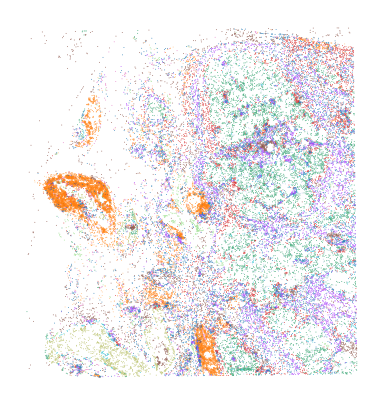

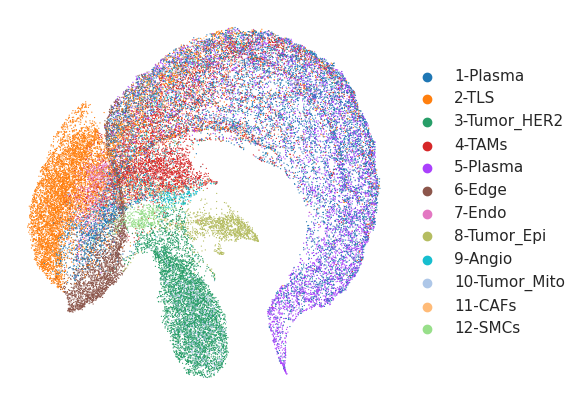

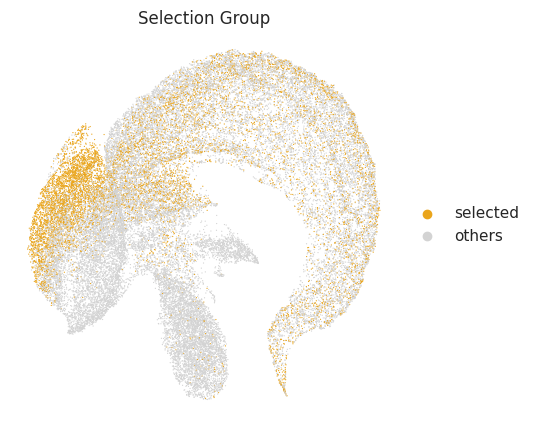

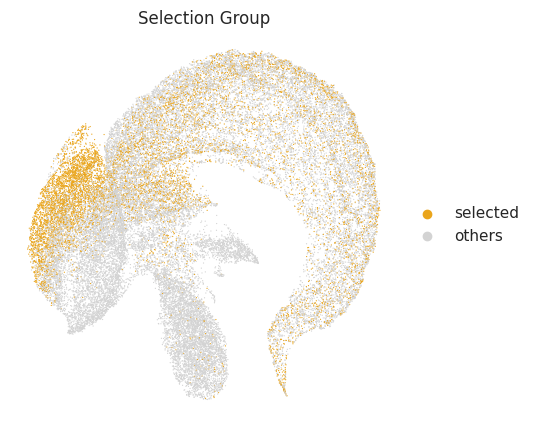

In [8]:
plot_spatial(orig_adata, "classification", "fig4a_hne", title="", spot_size=1.5, size=20, legend_loc=None)
plot_umap(orig_adata, "annotation", "fig4b_original_annotation_umap", title="")
plot_umap(
    pare_adata,
    "selection_group",
    "fig4c_pare_selection_umap",
    title="Selection Group",
    palette={"selected": "#eaa51b", "others": "#d3d3d3"},
)


## Fig. 4d-f: PARE clusters in latent UMAP, spatial coordinates, and original UMAP layout


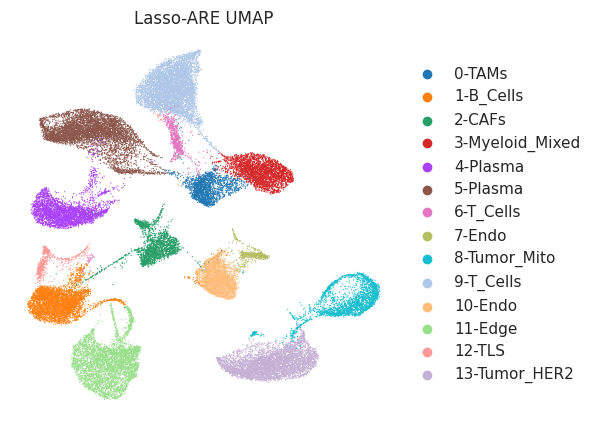

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)


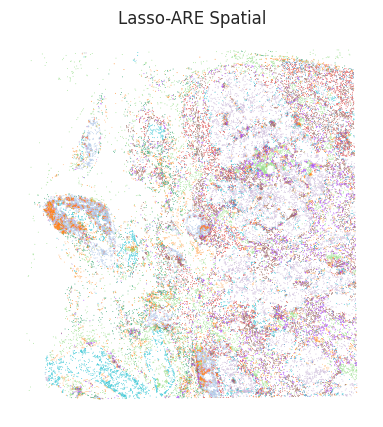

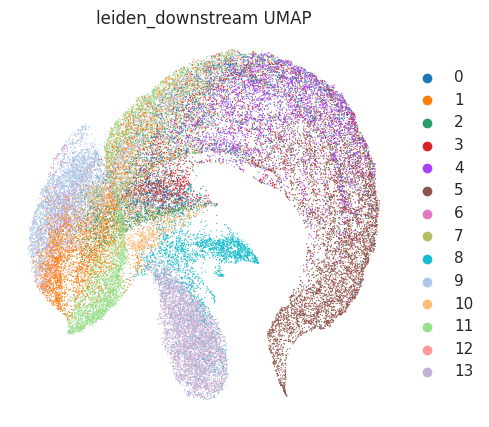

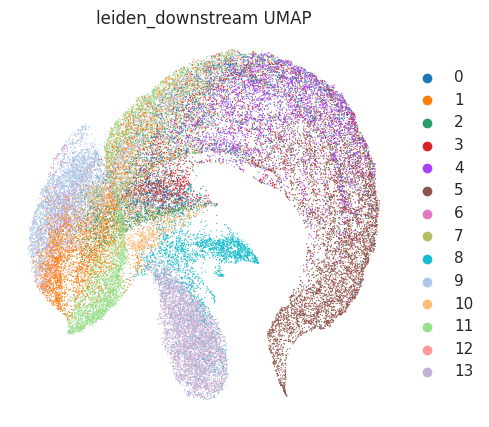

In [5]:
use_obsm_as_umap(pare_adata, "X_umap_LassoARE")
plot_umap(pare_adata, "anno_lare", "fig4d_pare_lassoare_umap", title="Lasso-ARE UMAP")
plot_spatial(pare_adata, "anno_lare", "fig4e_pare_lassoare_spatial", title="Lasso-ARE Spatial")

align_to_original_umap(pare_adata, orig_adata)
use_obsm_as_umap(pare_adata, "X_umap_original_layout")
plot_umap(pare_adata, "leiden_downstream", "fig4f_pare_original_layout_umap", title="leiden_downstream UMAP")


## Fig. 4g: TLS/T-cell spatial crop comparisons


In [6]:
from itertools import cycle


def highlight_spatial_crop(
    adata,
    cluster_key,
    highlight_values,
    name,
    title="",
    coord_x=(0, 4000),
    coord_y=(6000, 10000),
    inverse=False,
):
    coords = np.asarray(adata.obsm["spatial"])
    mask = (coords[:, 0] >= coord_x[0]) & (coords[:, 0] <= coord_x[1]) & (coords[:, 1] >= coord_y[0]) & (coords[:, 1] <= coord_y[1])
    cropped = adata[mask].copy()
    new_col = f"{cluster_key}_highlight"
    cropped.obs[new_col] = cropped.obs[cluster_key].astype(str)

    highlight_values = {str(v) for v in highlight_values}
    if inverse:
        cropped.obs.loc[cropped.obs[new_col].isin(highlight_values), new_col] = "Others"
    else:
        cropped.obs.loc[~cropped.obs[new_col].isin(highlight_values), new_col] = "Others"

    unique_groups = sorted(cropped.obs[new_col].unique())
    palette = {group: color for group, color in zip(unique_groups, cycle(sc.pl.palettes.default_20))}
    palette["Others"] = "lightgrey"
    order_idx = (
        cropped.obs.assign(__order__=(cropped.obs[new_col] != "Others").astype(int))
        .sort_values(["__order__", new_col])
        .index
    )
    return plot_spatial(cropped[order_idx], new_col, name=name, title=title, palette=palette, legend_loc="right margin")


/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


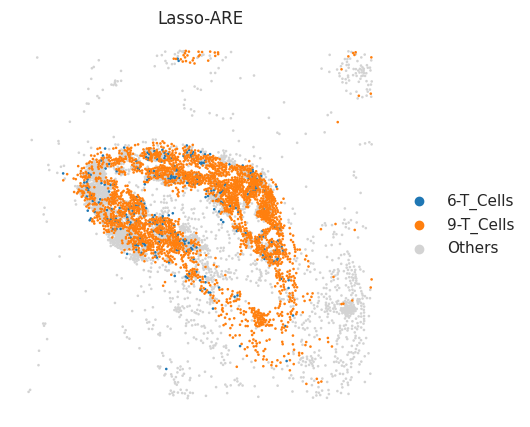

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


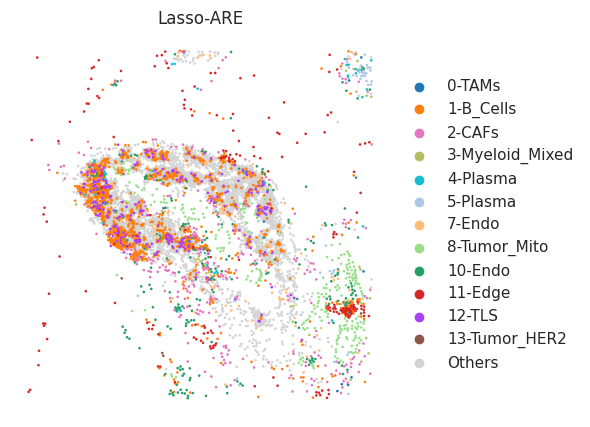

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


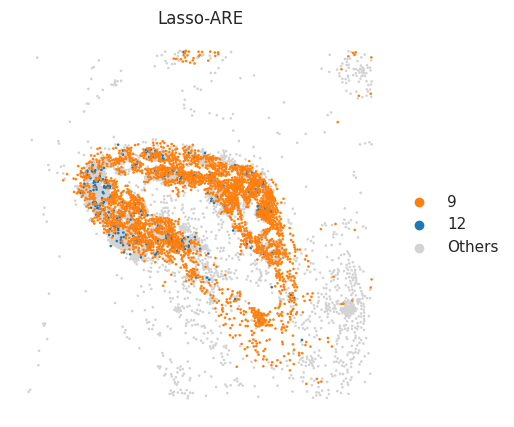

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


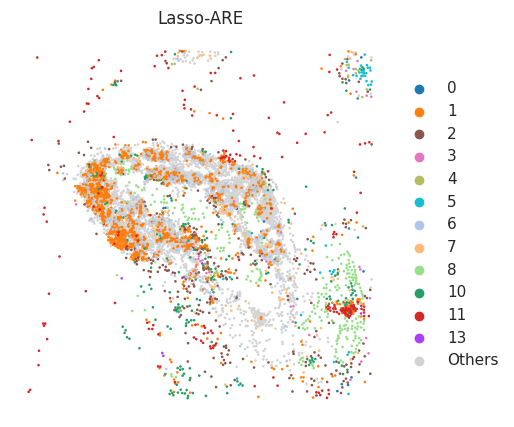

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


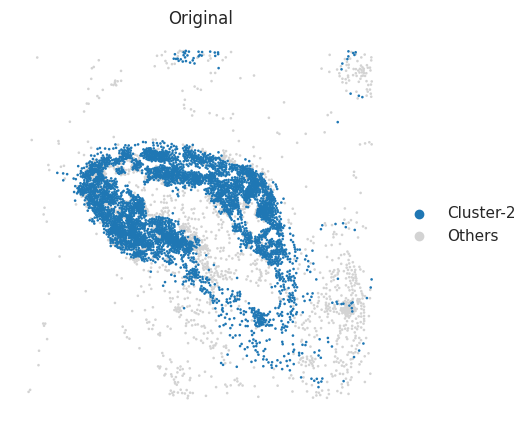

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


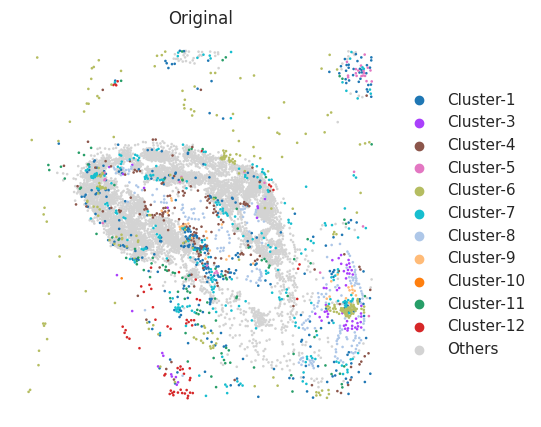

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


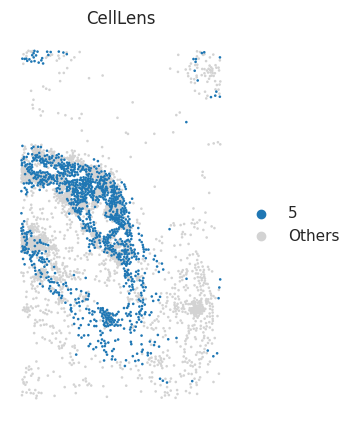

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


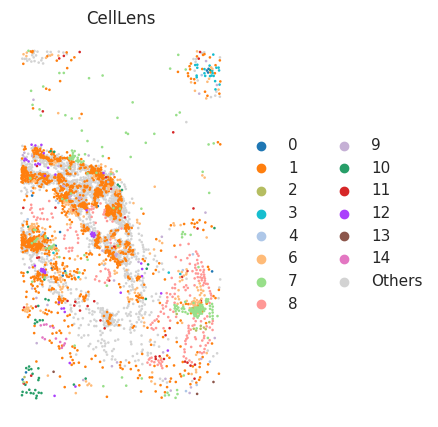

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


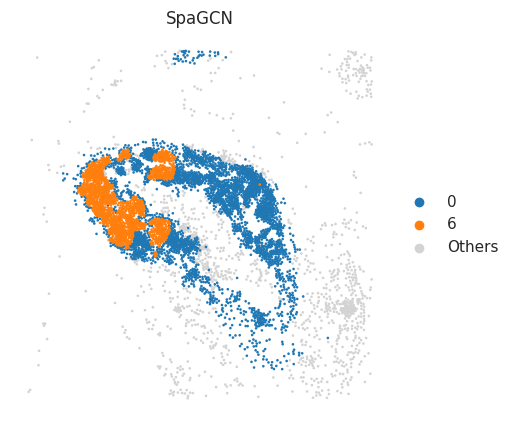

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


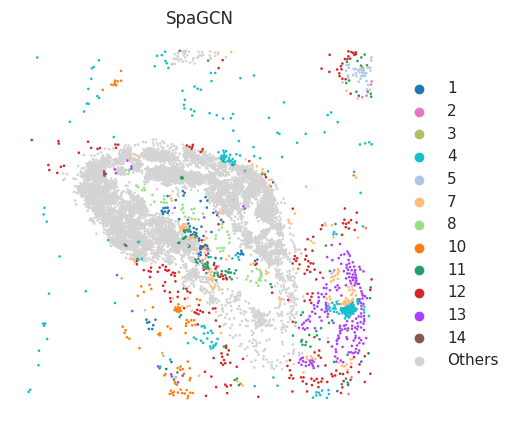

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


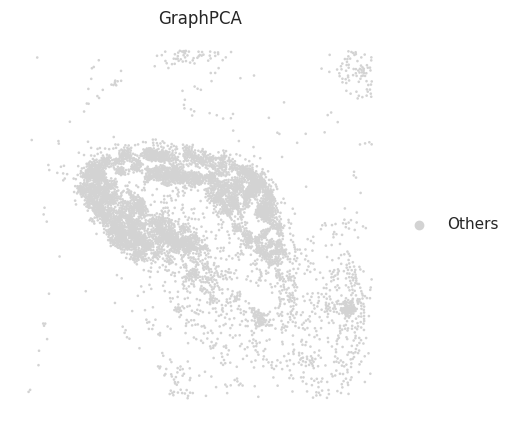

/tmp/ipykernel_1611734/3040077068.py:61: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, **kwargs)
/home/zzj/anaconda3/envs/env1/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


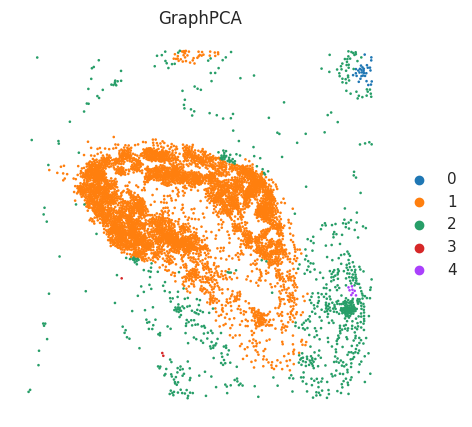

In [7]:
# PARE annotation-level T-cell highlight, matching draw_T_TLS_1.ipynb.
highlight_spatial_crop(
    pare_adata,
    cluster_key="anno_lare",
    highlight_values=["6-T_Cells", "9-T_Cells"],
    name="fig4g_pare_t_cells_crop",
    title="Lasso-ARE",
    inverse=False,
)
highlight_spatial_crop(
    pare_adata,
    cluster_key="anno_lare",
    highlight_values=["6-T_Cells", "9-T_Cells"],
    name="fig4g_pare_non_t_cells_crop",
    title="Lasso-ARE",
    inverse=True,
)

# Method-level TLS/T-cell crop comparisons, matching draw_T_TLS_2.ipynb.
method_crop_configs = [
    ("Lasso-ARE", PARE_PATH, "leiden_downstream", ["9", "12"]),
    ("Original", ORIG_PATH, "classification", ["Cluster-2"]),
    ("CellLens", CELLENS_PATH, "celllens_cluster", ["5"]),
    ("SpaGCN", SPAGCN_PATH, "refined_pred", ["0", "6"]),
    ("GraphPCA", GPCA_PATH, "gPCA_leiden_0.1", [""]),
]
for method, path, cluster_key, highlight_values in method_crop_configs:
    adata = sc.read_h5ad(path)
    highlight_spatial_crop(
        adata,
        cluster_key=cluster_key,
        highlight_values=highlight_values,
        name=f"fig4g_{method.replace(' ', '_').replace('-', '_')}_target_crop",
        title=method,
        inverse=False,
    )
    highlight_spatial_crop(
        adata,
        cluster_key=cluster_key,
        highlight_values=highlight_values,
        name=f"fig4g_{method.replace(' ', '_').replace('-', '_')}_background_crop",
        title=method,
        inverse=True,
    )


## Display saved PNG outputs

Run this cell after the plotting cells above to render the saved PNG files directly inside the notebook for review.

In [ ]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def display_saved_pngs(output_dir, width=1000):
    output_dir = Path(output_dir)
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}. Run the plotting cells above first.")
        return
    for png in pngs:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png), width=width))


In [ ]:
display_saved_pngs(OUTPUT_DIR, width=900)
